<a href="https://colab.research.google.com/github/atharva7279/my_deeplearning/blob/main/learning_CompVision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Computer vision - enabling computer to identify and process obj , img and vid as humans sdo

In [1]:
# CNN over NN (why cnn is better for image CV)
# concolutional layer
# conv layer -> relu layer -> pooling layer
# mnist dataset

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets , transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
# convert mnist image files into tensor of 4 dimnesions
# number of image , height , width , colour channel
transform = transforms.ToTensor()

In [4]:
# train data
train_data = datasets.MNIST(root = '/cnn_data', train=True, download=True, transform=transform)



100%|██████████| 9.91M/9.91M [00:00<00:00, 41.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.11MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]


In [5]:
test_data = datasets.MNIST(root = '/cnn_data', train=False, download=True, transform=transform)


In [6]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /cnn_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [7]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: /cnn_data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [8]:
pwd

'/content'

In [9]:
ls

sample_data/


In [10]:
cd ../

/


In [11]:
pwd

'/'

In [12]:
ls

bin@       datalab/  kaggle/  libx32@  proc/               run/   tmp/
boot/      dev/      lib@     media/   python-apt/         sbin@  tools/
cnn_data/  etc/      lib32@   mnt/     python-apt.tar.xz*  srv/   usr/
content/   home/     lib64@   opt/     root/               sys/   var/


In [13]:
cd cnn_data

/cnn_data


In [14]:
ls

MNIST/


In [15]:
cd ../

/


In [16]:
ls

bin@       datalab/  kaggle/  libx32@  proc/               run/   tmp/
boot/      dev/      lib@     media/   python-apt/         sbin@  tools/
cnn_data/  etc/      lib32@   mnt/     python-apt.tar.xz*  srv/   usr/
content/   home/     lib64@   opt/     root/               sys/   var/


In [17]:
cd content

/content


In [18]:
pwd

'/content'

In [19]:
 # create a small batch size for images
train_loader = DataLoader(train_data , batch_size=10 , shuffle=True)
test_loader = DataLoader(test_data , batch_size=10 , shuffle=False)


In [20]:
# Define CNN model
conv1 = nn.Conv2d(1 , 6 , 3 , 1)
conv2 = nn.Conv2d(6 , 16 , 3 , 1)

In [22]:
#grab 1 mnist image
for i, (X_train , y_train) in enumerate(train_data):
  break


In [25]:
X_train.shape

torch.Size([1, 28, 28])

In [29]:
x = X_train.view(1,1,28,28)

In [30]:
x = F.relu(conv1(x))

In [31]:
x.shape

torch.Size([1, 6, 26, 26])

In [33]:
# pass through polling layer
x = F.max_pool2d(x,2,2)

In [34]:
x.shape

torch.Size([1, 6, 13, 13])

In [35]:
# second conv layer
x = F.relu(conv2(x))

In [36]:
x.shape

torch.Size([1, 16, 11, 11])

In [37]:
x = F.max_pool2d(x,2,2)

In [38]:
x.shape

torch.Size([1, 16, 5, 5])

In [41]:
# Model class
class ConvolutionalNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 6, 3, 1)
    self.conv2 = nn.Conv2d(6, 16, 3, 1)
    # fully connected layer
    self.fc1 = nn.Linear(5*5*16, 120)
    self.fc2 = nn.Linear(120 , 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, X):
    X = F.relu(self.conv1(X))
    X = F.max_pool2d(X,2,2)
    # second pass
    X = F.relu(self.conv2(X))
    X = F.max_pool2d(X,2,2)
    # re-view to flatten it oout
    X = X.view(-1 , 16*5*5)
    # fully connected layers
    X = F.relu(self.fc1(X))
    X = F.relu(self.fc2(X))
    X = self.fc3(X)

    return F.log_softmax(X, dim=1)

In [42]:
# create an instance of model

torch.manual_seed(41)
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [43]:
# loss function optimizer

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [46]:
import time
start_time = time.time()
# create variables to track things
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

# loop over epochs
for i in range(epochs):
  trn_corr = 0
  tst_corr = 0

  #train
  for b, (X_train , y_train) in enumerate(train_loader):
    b+=1
    y_pred = model(X_train)
    loss = criterion(y_pred , y_train)
    predicted = torch.max(y_pred.data , 1)[1]
    batch_corr = (predicted == y_train).sum()
    trn_corr += batch_corr
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if b%600 == 0:
      print(f'epoch: {i}  loss: {loss.item()}  batch: {b}')
  train_losses.append(loss)
  train_correct.append(trn_corr)

#test
with torch.no_grad():
  for b, (X_test , y_test) in enumerate(test_loader):
    y_val = model(X_test)
    predicted = torch.max(y_val.data , 1)[1]
    tst_corr += (predicted == y_test).sum()
  loss = criterion(y_val , y_test)
  test_losses.append(loss)
  test_correct.append(tst_corr)

current_time = time.time()
total_time = current_time - start_time
print(f'Training Took: {total_time/60} minutes')

epoch: 0  loss: 0.0010309864301234484  batch: 600
epoch: 0  loss: 5.996130312269088e-06  batch: 1200
epoch: 0  loss: 0.42854493856430054  batch: 1800
epoch: 0  loss: 0.010709562338888645  batch: 2400
epoch: 0  loss: 0.00011397692287573591  batch: 3000
epoch: 0  loss: 1.5484676623600535e-05  batch: 3600
epoch: 0  loss: 0.000347492634318769  batch: 4200
epoch: 0  loss: 0.00020559551194310188  batch: 4800
epoch: 0  loss: 0.00011045084102079272  batch: 5400
epoch: 0  loss: 6.464038597187027e-05  batch: 6000
epoch: 1  loss: 0.000742987438570708  batch: 600
epoch: 1  loss: 0.025472277775406837  batch: 1200
epoch: 1  loss: 4.008401447208598e-05  batch: 1800
epoch: 1  loss: 0.005761544220149517  batch: 2400
epoch: 1  loss: 0.00036687497049570084  batch: 3000
epoch: 1  loss: 1.3112575288687367e-05  batch: 3600
epoch: 1  loss: 0.00019114163296762854  batch: 4200
epoch: 1  loss: 0.00252026435919106  batch: 4800
epoch: 1  loss: 0.002212937455624342  batch: 5400
epoch: 1  loss: 2.3803420845069923e-

In [47]:
test_load_everything = DataLoader(test_data , batch_size=10000 , shuffle=False)

In [48]:
with torch.no_grad():
  correct = 0
  for X_test , y_test in test_load_everything:
    y_val = model(X_test)
    predicted = torch.max(y_val,1)[1]
    correct += (predicted == y_test).sum()

In [49]:
correct.item()/len(test_data)*100

98.77

In [50]:
test_data[4143]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [51]:
test_data[4143][0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [53]:
# reshape
test_data[4143][0].reshape(28,28)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

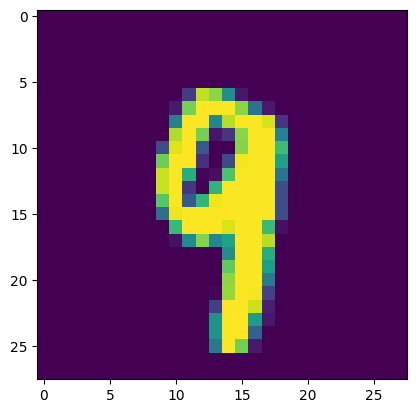

In [54]:
# show the image
plt.imshow(test_data[4143][0].reshape(28,28))

In [55]:
model.eval()
with torch.no_grad():
  new_prediction = model(test_data[4143][0].view(1,1,28,28))

In [56]:
new_prediction

tensor([[-2.5914e+01, -1.8286e+01, -2.1521e+01, -2.0285e+01, -7.0844e+00,
         -2.0994e+01, -4.1943e+01, -9.9519e+00, -1.5277e+01, -8.8640e-04]])

In [58]:
new_prediction.argmax()

tensor(9)